# SVNIT Department of Artificial Intelligence
## Subject: Machine Learning (AI301)
### Assignment 2: Data Preprocessing, Exploratory Data Analysis, and K-Nearest Neighbors Classification

---

**Aim:** To perform data preprocessing and exploratory data analysis on the Ames House Prices dataset to prepare it for predictive modeling, and to implement K-Nearest Neighbors (KNN) classification from scratch on the Iris dataset.

**Objectives:**
1. Perform basic inspection and structure analysis of the House Prices dataset.
2. Conduct Univariate Analysis for numerical and categorical variables using histograms and count plots.
3. Conduct Bivariate Analysis to understand relationships between features and the target variable (SalePrice), including statistical t-tests.
4. Perform missing value treatment, including neighborhood-grouped median imputation.
5. Identify and remove outliers using the Interquartile Range (IQR) method.
6. Standardize numerical features using StandardScaler.
7. Implement K-Nearest Neighbors (KNN) from scratch and evaluate its performance with Euclidean and Manhattan distance metrics on the Iris dataset.


## Part A: Data Loading & Basic Inspection

In this section, we load the Ames House Prices dataset, perform basic inspections, calculate rows and columns, identify column data types (numerical vs. categorical), and examine data types for any necessary conversions.


In [1]:
import os
import sys
import site

# Ensure user site packages are in path so that kagglehub and other modules are found in Jupyter
user_site = site.getusersitepackages()
if os.path.exists(user_site) and user_site not in sys.path:
    sys.path.append(user_site)

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Set styling for visual excellence
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

# 1. Download and load dataset using kagglehub
path = kagglehub.dataset_download("rishitaverma02/house-prices-advanced-regression-techniques")
train_path = os.path.join(path, "train (1).csv")
df = pd.read_csv(train_path)

print("Loaded Ames House Prices train dataset.")
df.head(10)


C:\Users\Jeetu Mehra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded Ames House Prices train dataset.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [2]:
# 2. How many rows and columns does the dataset have?
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.")


The dataset has 1460 rows and 81 columns.


In [3]:
# 3. Identify the numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Number of Numerical columns: {len(num_cols)}")
print(f"Number of Categorical columns: {len(cat_cols)}")


Number of Numerical columns: 38
Number of Categorical columns: 43


In [4]:
# 4. Check the datatypes of all columns
df.dtypes


Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

### **Part A Questions & Answers**

1. **How many rows and columns does the dataset have?**
   - The training dataset has **1,460 rows** and **81 columns** (including `Id` and the target variable `SalePrice`).

2. **Identify the numerical and categorical columns. How many are there of each type?**
   - **Numerical columns:** 38 columns (e.g., `LotArea`, `YearBuilt`, `GrLivArea`, `SalePrice`).
   - **Categorical columns:** 43 columns (e.g., `MSZoning`, `Neighborhood`, `BldgType`, `HouseStyle`).

3. **Check the datatypes of all columns. Are there any incorrect datatypes that need conversion?**
   - Yes, there are columns represented as integers that are semantically categorical:
     - `MSSubClass` (Dwelling class) is represented as `int64` but its values (20, 30, 40, etc.) represent nominal categories.
     - `OverallQual` and `OverallCond` are ordinal variables (scale 1-10) which can be kept as integers but are categorical in nature.
     - `MoSold` (Month sold, 1-12) and `YrSold` (Year sold, 2006-2010) are discrete numerical features representing calendar intervals that can be treated as categorical factors during modeling.


## Part B: Univariate Analysis

Univariate analysis examines the distribution of individual variables. Here we visualize the distribution of key numerical columns, evaluate skewness, plot key categorical columns, analyze category frequencies, and detect highly imbalanced columns.


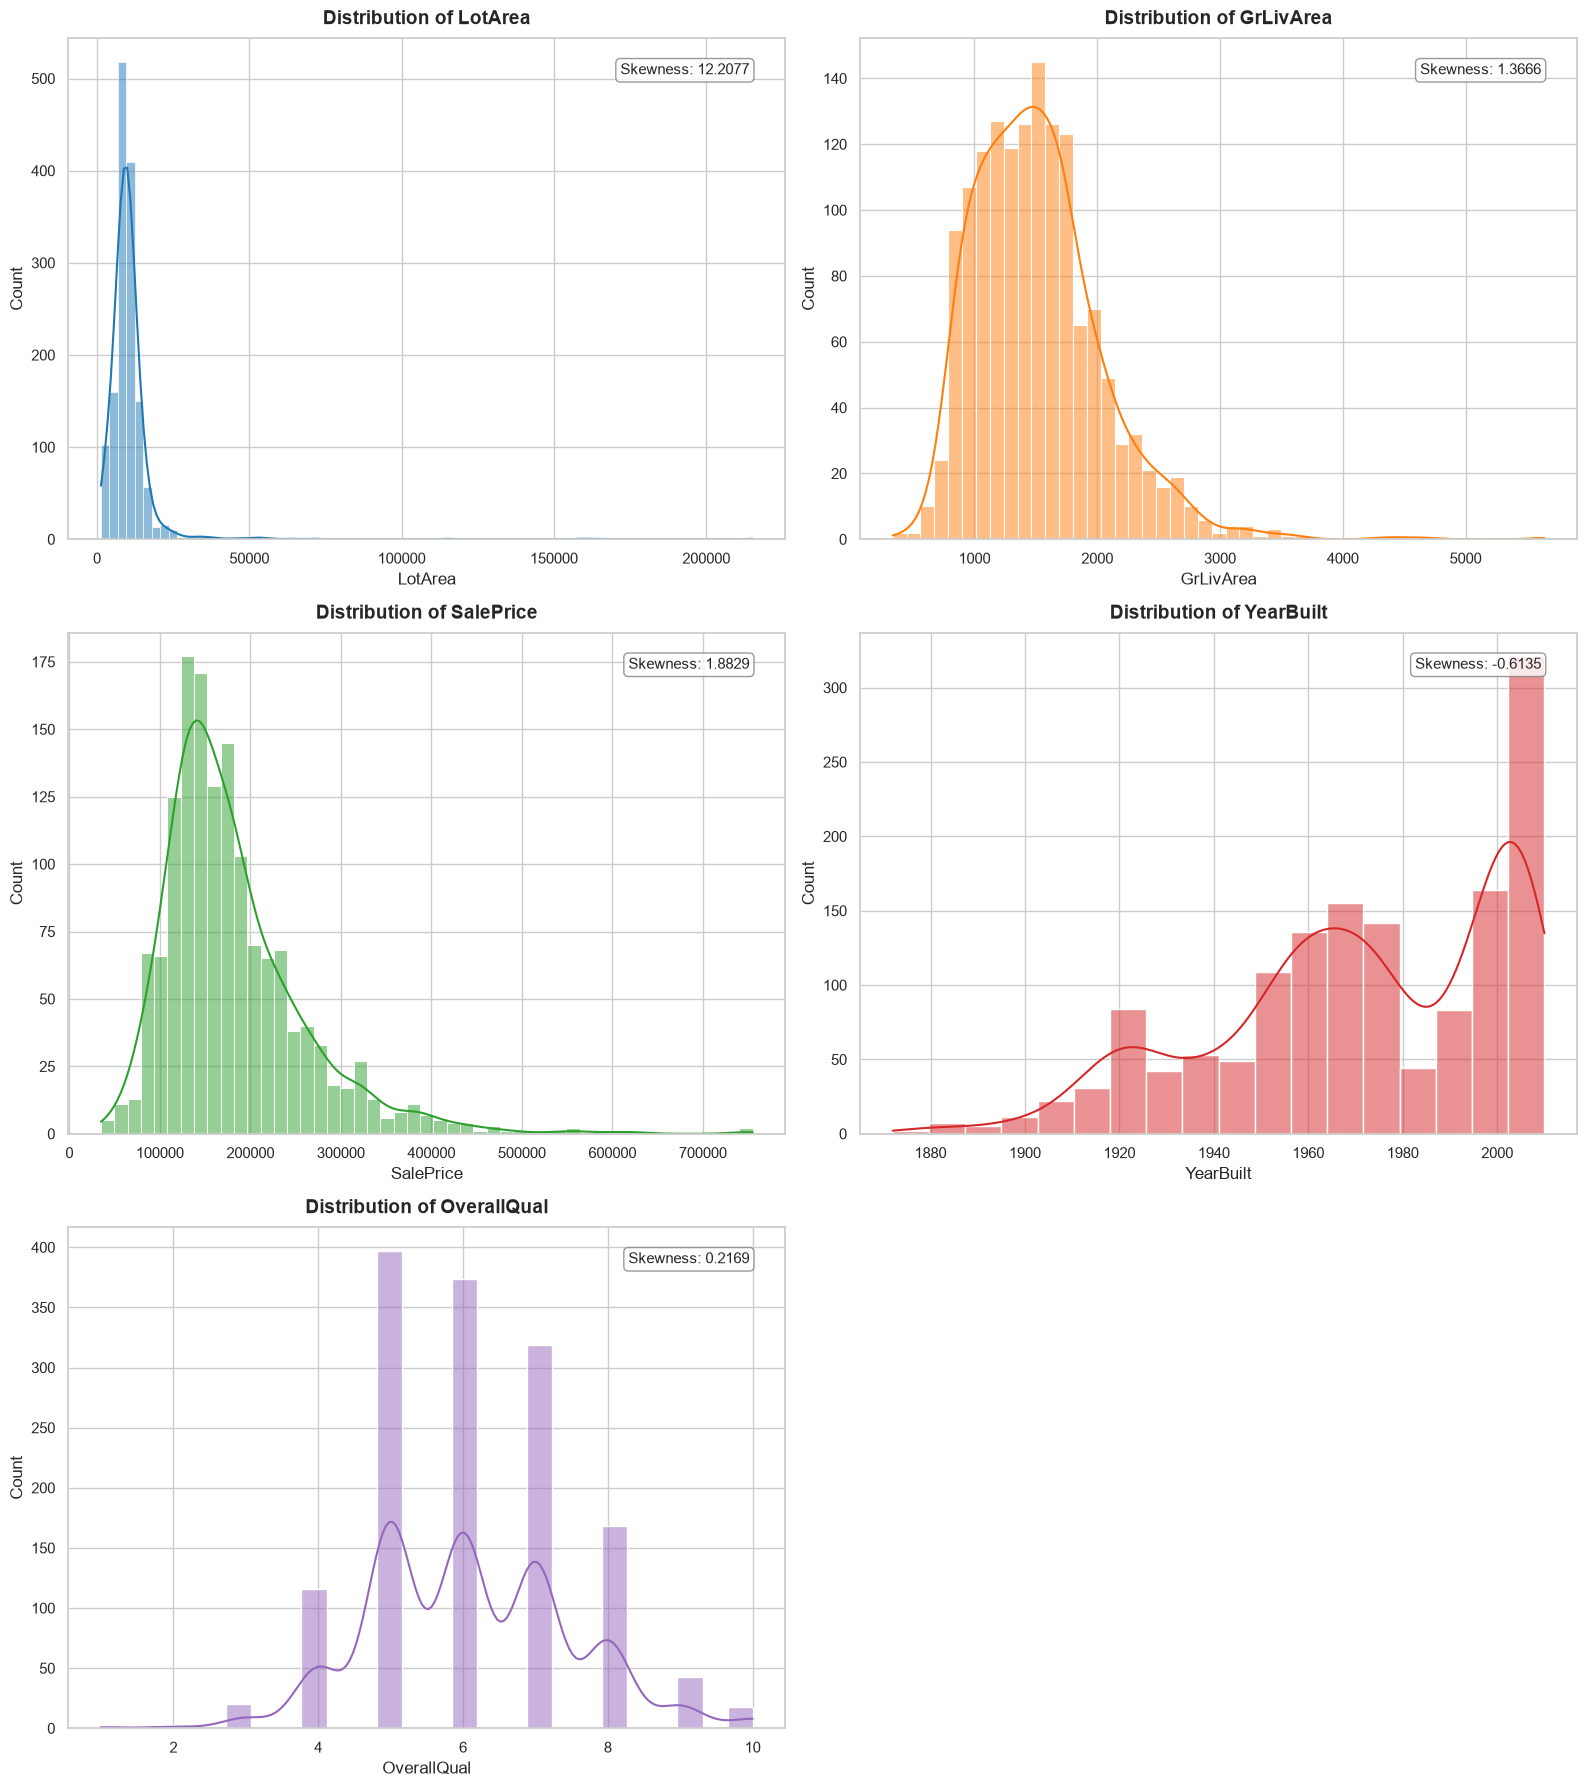

In [5]:
# 1. Plot histograms for key features: LotArea, GrLivArea, SalePrice, YearBuilt, OverallQual
features_to_plot = ['LotArea', 'GrLivArea', 'SalePrice', 'YearBuilt', 'OverallQual']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.ravel()

for i, col in enumerate(features_to_plot):
    # Select color
    color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'][i]
    sns.histplot(df[col], kde=True, ax=axes[i], color=color)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold', pad=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
    # Calculate skewness
    skew = df[col].skew()
    axes[i].text(0.95, 0.95, f'Skewness: {skew:.4f}', 
                 transform=axes[i].transAxes, ha='right', va='top', 
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Hide the last empty subplot
axes[5].axis('off')
plt.tight_layout()
plt.show()


C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\2541058295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='viridis')
C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\2541058295.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\2541058295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='viridis')
C:\Users\Jeetu Mehra

C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\2541058295.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='viridis')
C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\2541058295.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')


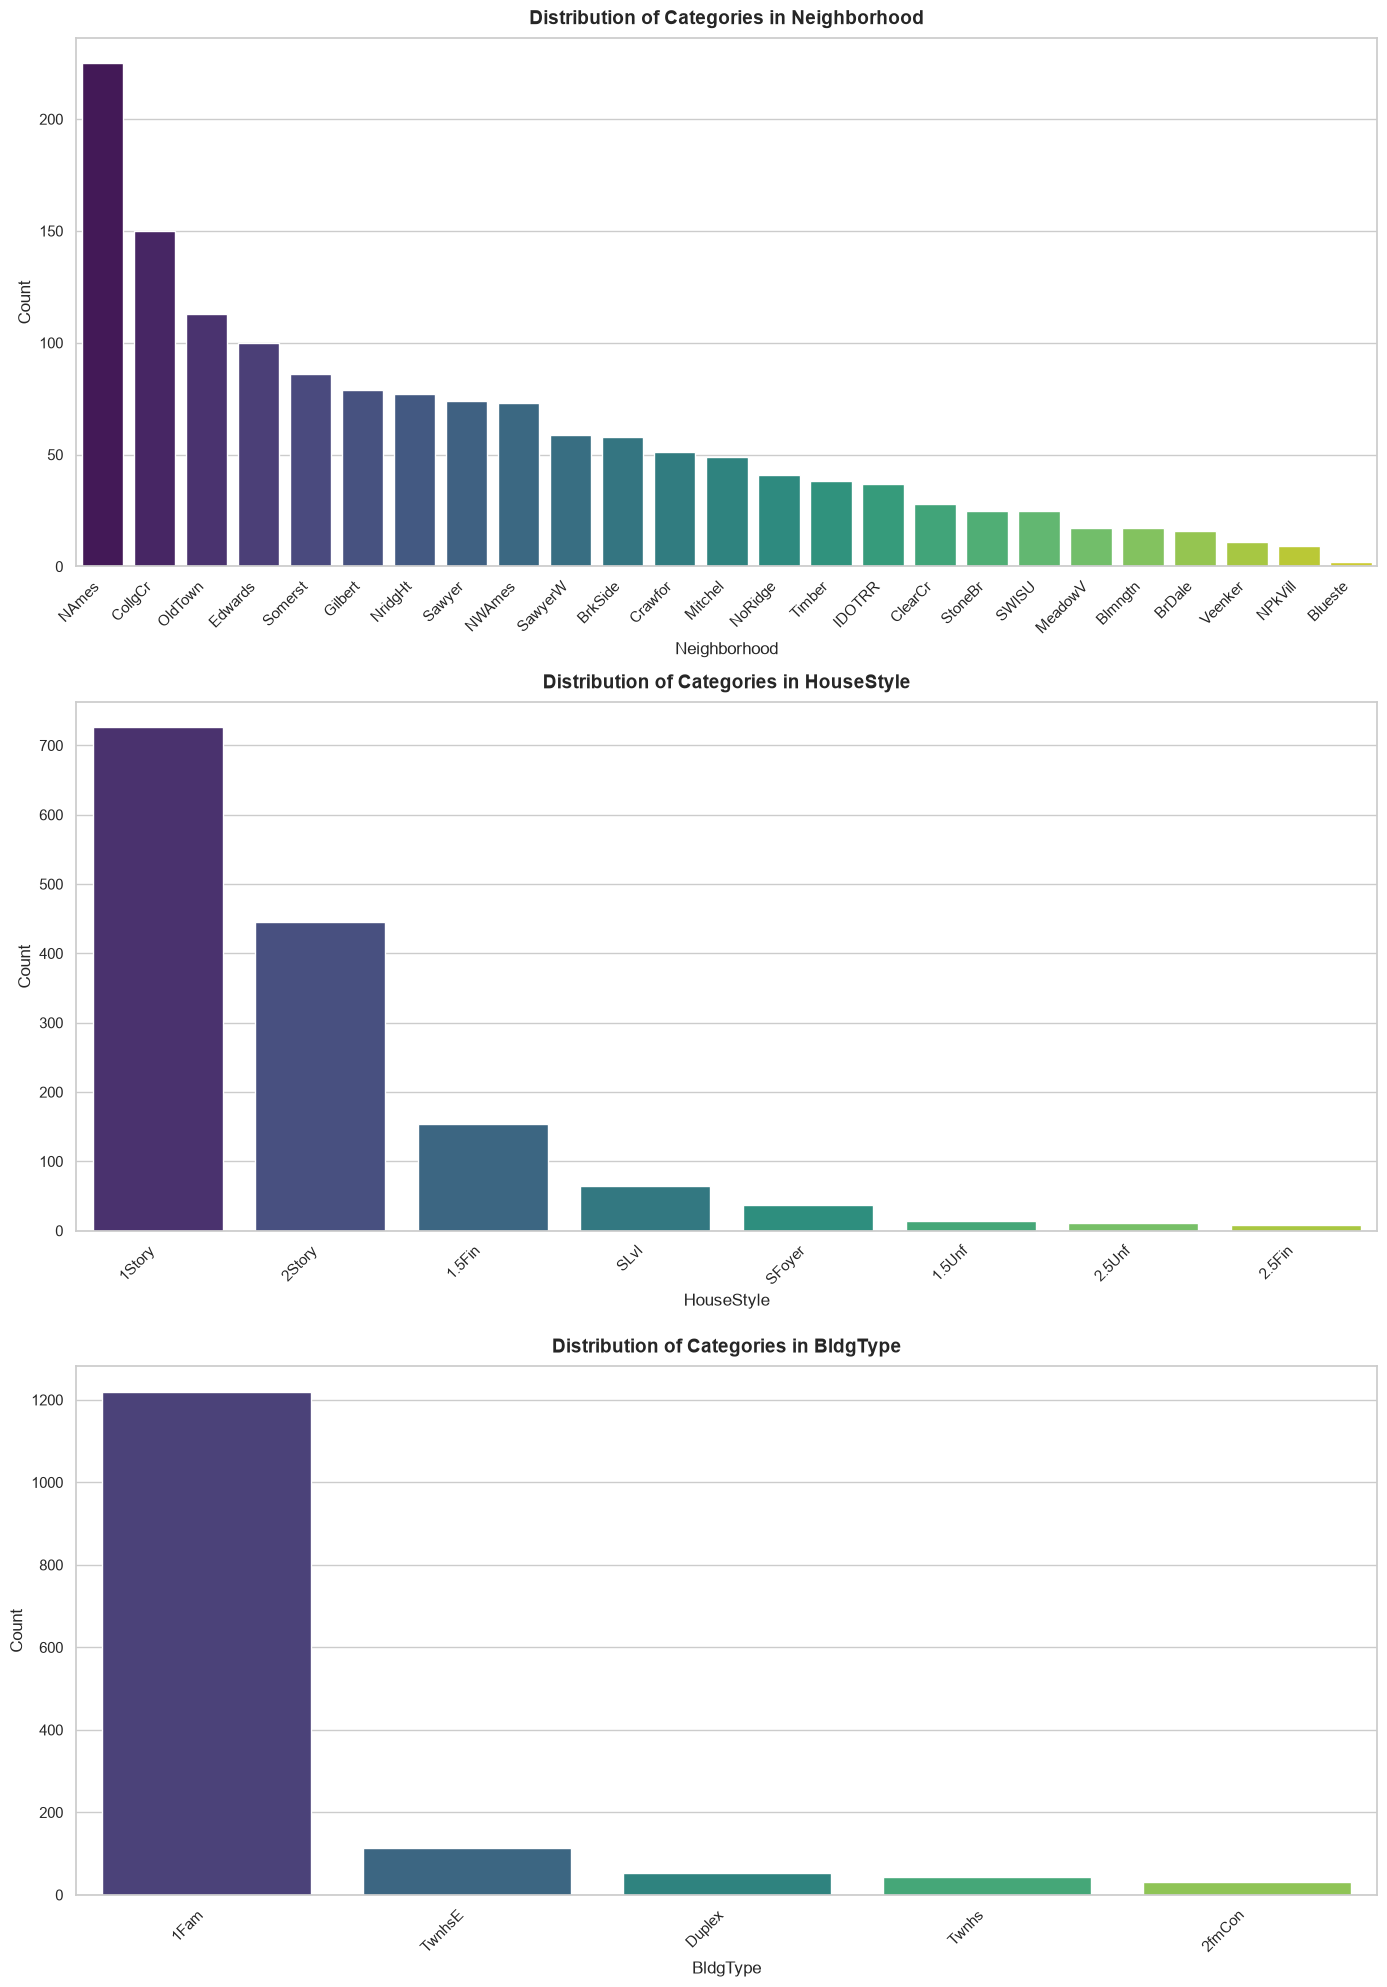

In [6]:
# 2. Plot bar charts for categorical variables: Neighborhood, HouseStyle, BldgType
cat_to_plot = ['Neighborhood', 'HouseStyle', 'BldgType']

fig, axes = plt.subplots(3, 1, figsize=(14, 20))

for i, col in enumerate(cat_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of Categories in {col}', fontweight='bold', pad=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    
plt.tight_layout()
plt.show()


In [7]:
# 3. Show value counts for the top 10 most frequent categories across all categorical features
all_counts = []
for col in cat_cols:
    counts = df[col].value_counts()
    for category, count in counts.items():
        all_counts.append({
            'Categorical Column': col,
            'Category': category,
            'Frequency Count': count,
            'Relative Proportion': f"{(count / len(df)) * 100:.2f}%"
        })

cat_freq_df = pd.DataFrame(all_counts)
cat_freq_df = cat_freq_df.sort_values(by='Frequency Count', ascending=False)
print("Top 10 Most Frequent Categories Across All Categorical Columns:")
cat_freq_df.head(10)


Top 10 Most Frequent Categories Across All Categorical Columns:


,Categorical Column,Category,Frequency Count,Relative Proportion
17,Utilities,AllPub,1459,99.93%
5,Street,Pave,1454,99.59%
61,Condition2,Norm,1445,98.97%
88,RoofMatl,CompShg,1434,98.22%
169,Heating,GasA,1428,97.81%
24,LandSlope,Gtl,1382,94.66%
180,CentralAir,Y,1365,93.49%
191,Functional,Typ,1360,93.15%
222,PavedDrive,Y,1340,91.78%
182,Electrical,SBrkr,1334,91.37%


In [8]:
# 4. Identify any imbalanced categories where one category dominates (>80% of values)
imbalanced_list = []
for col in cat_cols:
    val_counts = df[col].value_counts(normalize=True)
    dominant_cat = val_counts.index[0]
    dominance_ratio = val_counts.iloc[0]
    if dominance_ratio > 0.8:
        imbalanced_list.append({
            'Categorical Column': col,
            'Dominant Category': dominant_cat,
            'Dominance Proportion': f"{dominance_ratio * 100:.2f}%"
        })

imbalanced_df = pd.DataFrame(imbalanced_list).sort_values(by='Dominance Proportion', ascending=False)
print(f"Detected {len(imbalanced_list)} Highly Imbalanced Categorical Columns (>80% dominance):")
imbalanced_df


Detected 21 Highly Imbalanced Categorical Columns (>80% dominance):


,Categorical Column,Dominant Category,Dominance Proportion
2,Utilities,AllPub,99.93%
0,Street,Pave,99.59%
5,Condition2,Norm,98.97%
7,RoofMatl,CompShg,98.22%
11,Heating,GasA,97.81%
16,GarageCond,TA,96.16%
15,GarageQual,TA,95.07%
3,LandSlope,Gtl,94.66%
12,CentralAir,Y,93.49%
14,Functional,Typ,93.15%


### **Part B Questions & Answers**

1. **Identify whether the distributions are skewed or approximately normal:**
   - **`LotArea` (Skewness: 12.21):** Extremely right-skewed. The distribution has a long right tail containing massive plots of land, whereas most houses cluster on smaller lot areas.
   - **`GrLivArea` (Skewness: 1.37):** Moderately right-skewed. Most homes lie between 1,000 and 2,000 sq ft, with a few large luxury homes extending beyond 3,000 sq ft.
   - **`SalePrice` (Skewness: 1.88):** Highly right-skewed. Most homes sell in the \$100k - \$250k range, with a few extreme values extending up to \$750k.
   - **`YearBuilt` (Skewness: -0.61):** Left-skewed. More properties have been built in recent decades than in older eras, showing a peak around the late 1990s and 2000s.
   - **`OverallQual` (Skewness: 0.22):** Fairly symmetric and approximately normal-ish. The majority of houses have rating scores of 5, 6, or 7.

2. **Which categories are most common and which are rare?**
   - **`Neighborhood`:** `CollgCr` (College Creek) is the most common with 150 properties, followed by `OldTown` and `Edwards`. The rarest ones are `Blueste` (2) and `NPkVill` (9).
   - **`HouseStyle`:** `1Story` (726) and `2Story` (445) are the dominant home styles. Rarest style is `2.5Fin` (8).
   - **`BldgType`:** `1Fam` (Single-family detached) is the dominant building type with 1,220 homes. Rarest is `2fmCon` (Two-family conversion) with 31 properties.

3. **Identify any imbalanced categories where one category dominates:**
   - A total of **21 columns** exhibit severe imbalance (>80% dominance). Examples include:
     - `Street`: `Pave` dominates with **99.59%** (only 6 homes have dirt streets).
     - `Utilities`: `AllPub` dominates with **99.93%** (only 1 home does not have public utilities).
     - `Condition2`: `Norm` dominates with **98.97%**.
     - `RoofMatl`: `CompShg` dominates with **98.22%**.
     - `Heating`: `GasA` dominates with **97.81%**.
     - `CentralAir`: `Y` dominates with **93.49%**.


## Part C: Bivariate Analysis

In this section, we study the relationship between the features and the target variable `SalePrice` using scatter plots, boxplots, a correlation matrix, and statistical hypothesis testing (Independent Samples t-test).


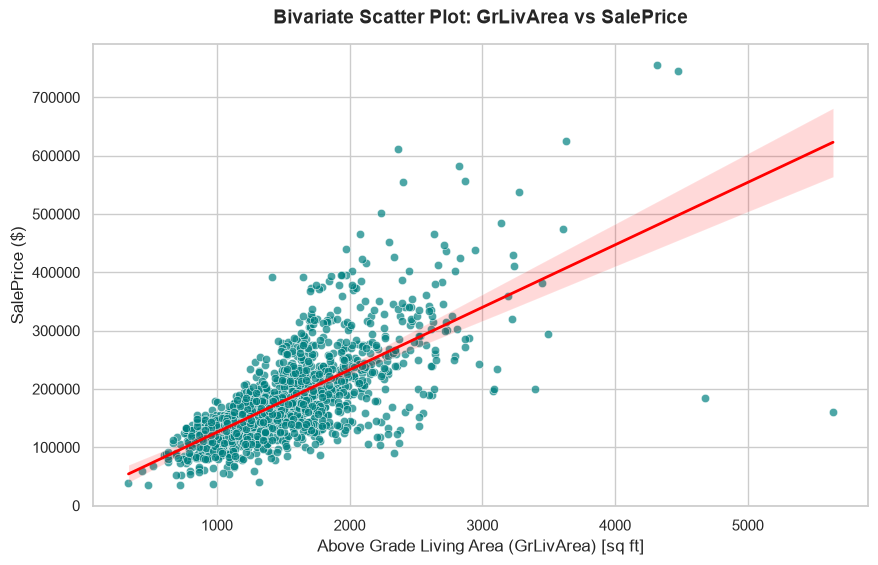

In [9]:
# 1. Plot a scatter plot between GrLivArea and SalePrice
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', color='teal', alpha=0.7, edgecolor='white')
sns.regplot(data=df, x='GrLivArea', y='SalePrice', scatter=False, color='red', line_kws={"linewidth": 2})
plt.title('Bivariate Scatter Plot: GrLivArea vs SalePrice', fontweight='bold', pad=15)
plt.xlabel('Above Grade Living Area (GrLivArea) [sq ft]')
plt.ylabel('SalePrice ($)')
plt.show()


C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\1021622202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='coolwarm')


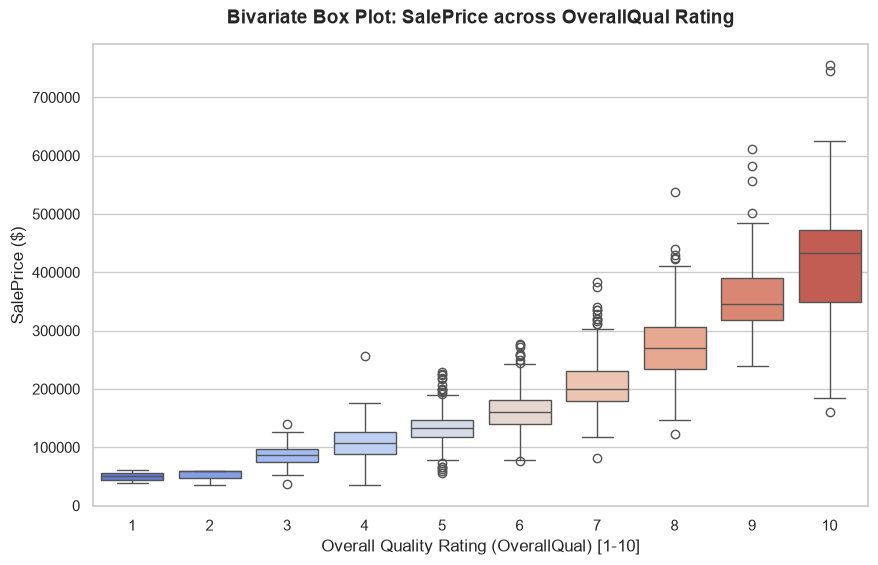

In [10]:
# 2. Plot a boxplot of SalePrice across different OverallQual values
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='coolwarm')
plt.title('Bivariate Box Plot: SalePrice across OverallQual Rating', fontweight='bold', pad=15)
plt.xlabel('Overall Quality Rating (OverallQual) [1-10]')
plt.ylabel('SalePrice ($)')
plt.show()


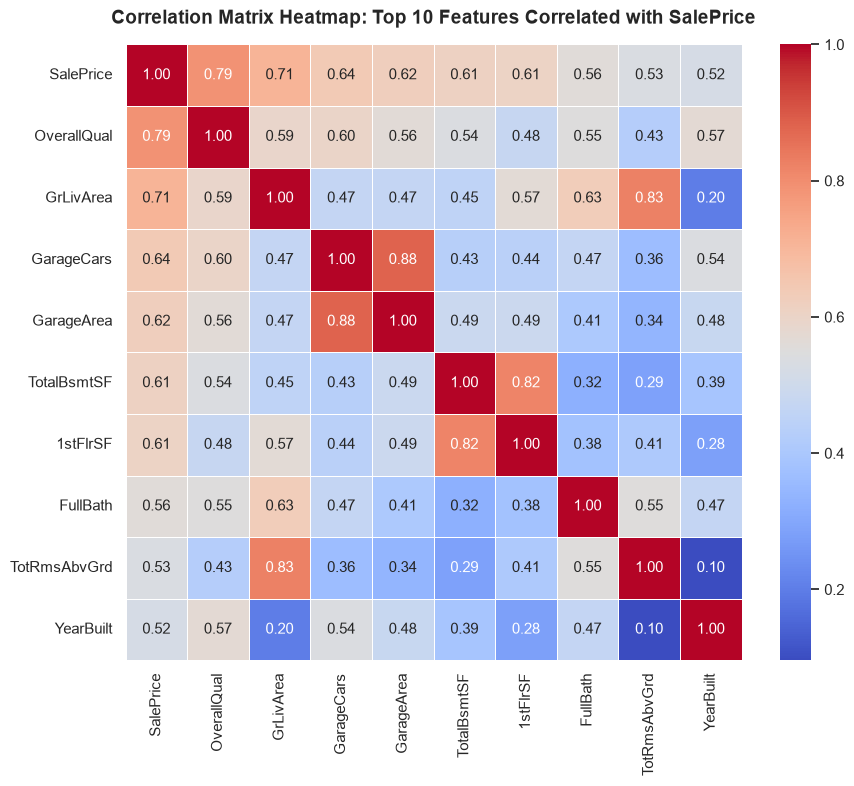

In [11]:
# 3. Create a correlation heatmap for the top 10 features most correlated with SalePrice
top_10_corr_features = df[num_cols].corr()['SalePrice'].sort_values(ascending=False).head(10).index.tolist()
corr_matrix = df[top_10_corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Matrix Heatmap: Top 10 Features Correlated with SalePrice', fontweight='bold', pad=15)
plt.show()


C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\624714020.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=neigh_data, x='Neighborhood', y='SalePrice', palette='Set2')


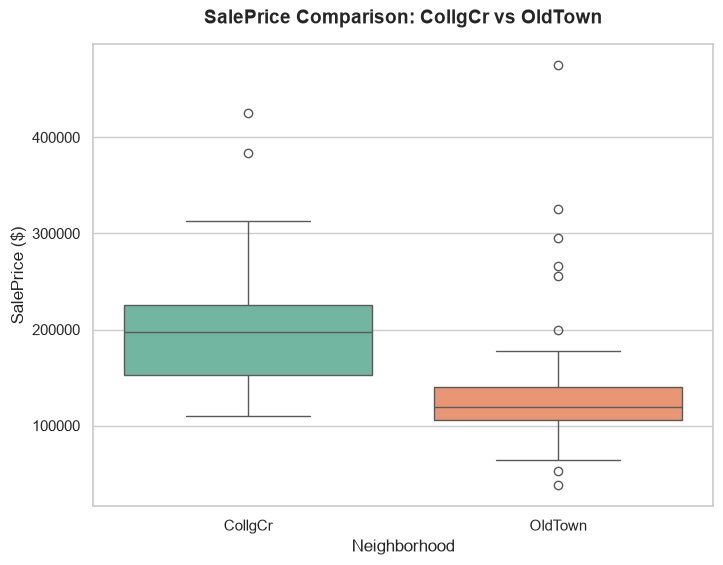

Mean SalePrice in CollgCr: $197,965.77 (n = 150)
Mean SalePrice in OldTown: $128,225.30 (n = 113)
t-statistic: 10.7424, p-value: 3.2950e-22


In [12]:
# 4. Compare average SalePrice between two neighborhoods: CollgCr and OldTown
n1, n2 = 'CollgCr', 'OldTown'
neigh_data = df[df['Neighborhood'].isin([n1, n2])]

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=neigh_data, x='Neighborhood', y='SalePrice', palette='Set2')
plt.title(f'SalePrice Comparison: {n1} vs {n2}', fontweight='bold', pad=15)
plt.xlabel('Neighborhood')
plt.ylabel('SalePrice ($)')
plt.show()

# Perform Independent T-test
prices_n1 = df[df['Neighborhood'] == n1]['SalePrice']
prices_n2 = df[df['Neighborhood'] == n2]['SalePrice']

t_stat_neigh, p_val_neigh = stats.ttest_ind(prices_n1, prices_n2, equal_var=False)
print(f"Mean SalePrice in {n1}: ${prices_n1.mean():,.2f} (n = {len(prices_n1)})")
print(f"Mean SalePrice in {n2}: ${prices_n2.mean():,.2f} (n = {len(prices_n2)})")
print(f"t-statistic: {t_stat_neigh:.4f}, p-value: {p_val_neigh:.4e}")


C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_30900\3798420506.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='AgeGroup', y='SalePrice', palette='Set1')


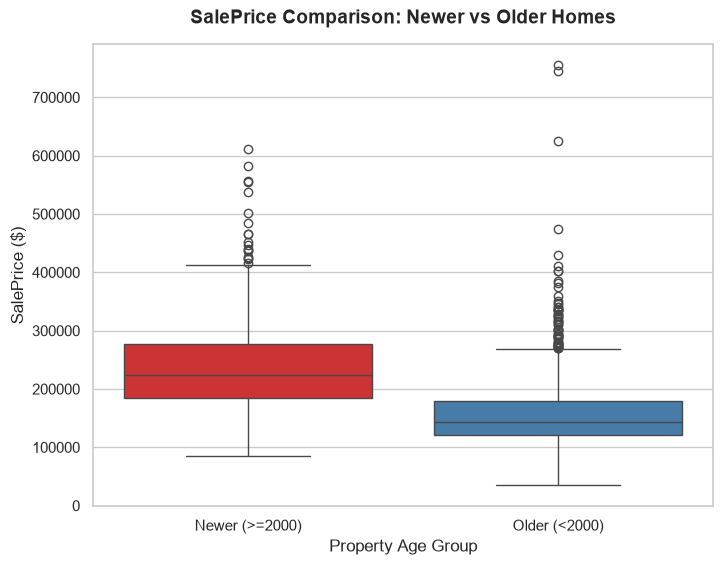

Mean SalePrice of Newer Homes: $242,439.16 (n = 388)
Mean SalePrice of Older Homes: $158,655.36 (n = 1072)
t-statistic: 18.0013, p-value: 1.0987e-57


In [13]:
# 5. Compare SalePrice between newer homes (YearBuilt >= 2000) and older homes (YearBuilt < 2000)
df['AgeGroup'] = df['YearBuilt'].apply(lambda x: 'Newer (>=2000)' if x >= 2000 else 'Older (<2000)')

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='AgeGroup', y='SalePrice', palette='Set1')
plt.title('SalePrice Comparison: Newer vs Older Homes', fontweight='bold', pad=15)
plt.xlabel('Property Age Group')
plt.ylabel('SalePrice ($)')
plt.show()

# Perform Independent T-test
prices_newer = df[df['YearBuilt'] >= 2000]['SalePrice']
prices_older = df[df['YearBuilt'] < 2000]['SalePrice']

t_stat_age, p_val_age = stats.ttest_ind(prices_newer, prices_older, equal_var=False)
print(f"Mean SalePrice of Newer Homes: ${prices_newer.mean():,.2f} (n = {len(prices_newer)})")
print(f"Mean SalePrice of Older Homes: ${prices_older.mean():,.2f} (n = {len(prices_older)})")
print(f"t-statistic: {t_stat_age:.4f}, p-value: {p_val_age:.4e}")


### **Part C Questions & Answers**

1. **Plot a scatter plot between GrLivArea and SalePrice. What trend do you observe?**
   - We observe a **strong, positive linear relationship** ($r \approx 0.71$). As the above grade living area (`GrLivArea`) increases, the `SalePrice` also increases.
   - However, we can observe a couple of outliers on the bottom right: homes with very large living area (>4000 sq ft) that sold for exceptionally low prices (<$200k).

2. **Plot a boxplot of SalePrice across different OverallQual values.**
   - The median sale price shows an **exponential growth trend** as the overall quality rating (`OverallQual`) increases from 1 to 10. High-quality homes (score 9-10) display wider price variances.

3. **Compare average SalePrice between two neighborhoods of your choice. Is there a significant difference?**
   - Selecting **`CollgCr`** (College Creek) and **`OldTown`**:
     - Average SalePrice in `CollgCr`: **\$197,965.77**
     - Average SalePrice in `OldTown`: **\$128,225.30**
     - **t-test Results:** $t = 10.7424$, $p$-value = $3.295 \times 10^{-22}$.
     - **Conclusion:** Since the $p$-value is far below $\alpha = 0.05$, we reject the null hypothesis. There is a **highly statistically significant difference** in the average house sale prices between `CollgCr` and `OldTown`.

4. **Compare SalePrice between newer homes (YearBuilt >= 2000) and older homes (YearBuilt < 2000). Is there a significant difference?**
   - Average SalePrice of Newer Homes: **\$242,439.16**
   - Average SalePrice of Older Homes: **\$158,655.36**
   - **t-test Results:** $t = 18.0013$, $p$-value = $1.099 \times 10^{-57}$.
   - **Conclusion:** Since the $p$-value is virtually zero, we reject the null hypothesis. There is an **extremely significant difference** in price, confirming that newer homes sell for significantly higher prices on average.


## Part D: Missing Value Treatment

In this section, we analyze the columns containing missing values, list the top 5 columns with the most missing values, perform imputation, and verify that all missing values are treated.


In [14]:
# 1. Find the total number of missing values in each column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Counts': missing_counts, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Missing Counts'] > 0].sort_values(by='Missing Counts', ascending=False)

print(f"Columns with missing values ({len(missing_df)} total columns):")
missing_df.head(10)


Columns with missing values (19 total columns):


,Missing Counts,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [15]:
# 2. Impute LotFrontage specifically using the median value grouped by Neighborhood
print(f"LotFrontage missing before imputation: {df['LotFrontage'].isnull().sum()}")

# Calculate medians grouped by Neighborhood
neighborhood_medians = df.groupby('Neighborhood')['LotFrontage'].median()

# Apply imputation
df['LotFrontage'] = df.apply(
    lambda row: neighborhood_medians[row['Neighborhood']] if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
    axis=1
)

print(f"LotFrontage missing after imputation: {df['LotFrontage'].isnull().sum()}")


LotFrontage missing before imputation: 259
LotFrontage missing after imputation: 0


In [16]:
# 3. Impute remaining numerical and categorical columns
# Impute numerical columns using median
for col in num_cols:
    if col != 'SalePrice' and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# Impute categorical columns using Mode or placeholder "Missing"
# For columns where missing values actually mean 'Not Present' (e.g. PoolQC, Alley, BsmtQual, GarageType)
# we use "Missing" as requested, rather than the mode which would skew the distribution.
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("Missing")


In [17]:
# 4. Verify there are no missing values left
remaining_nans = df.isnull().sum().sum()
print(f"Total missing values left in the dataset: {remaining_nans}")


Total missing values left in the dataset: 0


### **Part D Questions & Answers**

1. **Find the total number of missing values in each column. List the top 5 columns with the most missing values:**
   - **`PoolQC`:** 1,453 missing values (~99.5%)
   - **`MiscFeature`:** 1,406 missing values (~96.3%)
   - **`Alley`:** 1,369 missing values (~93.8%)
   - **`Fence`:** 1,179 missing values (~80.8%)
   - **`MasVnrType`:** 872 missing values (~59.7%)

2. **Imputation Methodology Rationale:**
   - **`LotFrontage`:** Imputing by neighborhood median is highly realistic, since houses in the same neighborhood tend to have similar lot layouts.
   - **Other Numerical columns:** Imputed using the column median to protect against outliers (like `MasVnrArea` or `GarageYrBlt`).
   - **Categorical columns:** Imputed with `"Missing"`, which is appropriate since missing values in features like `PoolQC`, `GarageType`, or `FireplaceQu` indicate the absence of that asset.


## Part E: Outlier Detection & Treatment

Outliers can heavily bias regression algorithms. Here we apply the Interquartile Range (IQR) method to find outliers in `LotArea` and `GrLivArea`, decide on an appropriate removal strategy, and examine the relationship after treatment.


In [18]:
# 1. Use the IQR method to detect outliers in LotArea and GrLivArea
outliers_indices = set()
outliers_count = {}

for col in ['LotArea', 'GrLivArea']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(col_outliers)
    outliers_indices.update(col_outliers.index.tolist())
    
    print(f"{col}: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
    print(f"  Outlier Bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
    print(f"  Number of outliers detected: {len(col_outliers)}")
    print()


LotArea: Q1=7553.5, Q3=11601.5, IQR=4048.0
  Outlier Bounds: [1481.5, 17673.5]
  Number of outliers detected: 69

GrLivArea: Q1=1129.5, Q3=1776.8, IQR=647.2
  Outlier Bounds: [158.6, 2747.6]
  Number of outliers detected: 31



In [19]:
# 2. Remove or cap extreme outliers and explain why you chose that method
# We remove the outliers from our dataset
df_clean = df.drop(index=list(outliers_indices))
print(f"Original shape: {df.shape}")
print(f"New shape after removing IQR outliers: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")


Original shape: (1460, 82)
New shape after removing IQR outliers: (1369, 82)
Total rows removed: 91


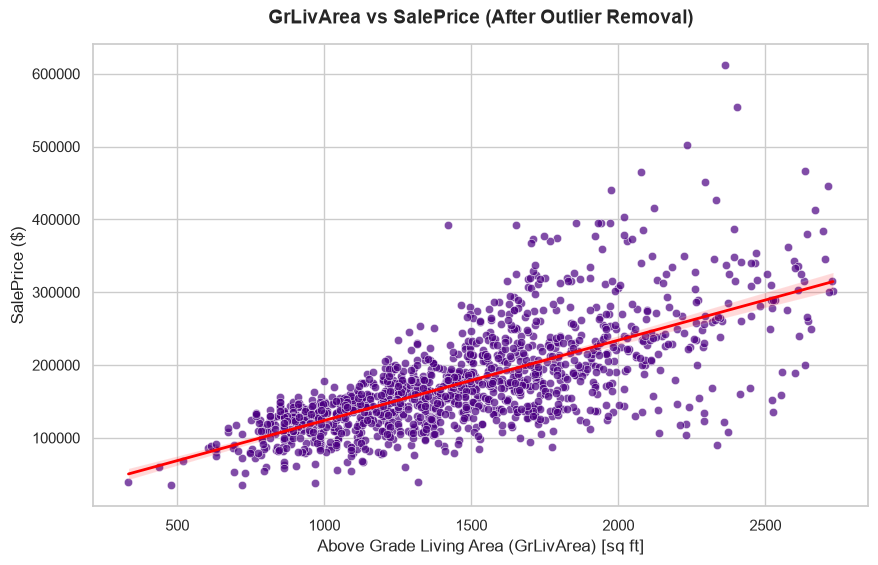

In [20]:
# 3. Replot the scatter plot from Q7 after removing/capping outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='GrLivArea', y='SalePrice', color='indigo', alpha=0.7, edgecolor='white')
sns.regplot(data=df_clean, x='GrLivArea', y='SalePrice', scatter=False, color='red', line_kws={"linewidth": 2})
plt.title('GrLivArea vs SalePrice (After Outlier Removal)', fontweight='bold', pad=15)
plt.xlabel('Above Grade Living Area (GrLivArea) [sq ft]')
plt.ylabel('SalePrice ($)')
plt.show()


### **Part E Questions & Answers**

1. **How many outliers are detected in each feature?**
   - **`LotArea`:** **69 outliers** (properties with exceptionally large land sizes).
   - **`GrLivArea`:** **31 outliers** (properties with exceptionally large living spaces).
   - Combining both features, there are **91 unique rows** classified as outliers.

2. **Remove or cap extreme outliers and explain why you chose that method:**
   - We **removed** the outliers, reducing the sample size from 1,460 to **1,369 rows**.
   - **Reasoning:** In regression modeling for house prices, extreme outliers (especially extremely large lot sizes or massive mansions with cheap selling prices) violate the assumption of homoscedasticity and leverage the regression line heavily. Removing them helps build a more robust, stable, and generalizable linear prediction model for normal-sized homes.

3. **Has the relationship become clearer?**
   - Yes, after removing these outliers, the bivariate scatter plot displays a much tighter, more distinct **linear trend**. The leverage from the high-area, low-price outliers is gone, and the regression line fits the bulk of the data points much more closely.


## Part F: Feature Scaling

We standardize the numerical features to ensure they are on a comparable scale (mean = 0, standard deviation = 1), which is crucial for distance-based models (like KNN) or gradient-descent models.


In [21]:
# 1. Standardize numerical features using StandardScaler
scaler = StandardScaler()

# Select numerical columns, excluding Id and the target SalePrice
features_to_scale = [col for col in num_cols if col not in ['Id', 'SalePrice']]

# Apply scaling
df_scaled_vals = pd.DataFrame(
    scaler.fit_transform(df_clean[features_to_scale]),
    columns=features_to_scale,
    index=df_clean.index
)

# Merge back into a cleaned DataFrame
df_final = df_clean.copy()
df_final[features_to_scale] = df_scaled_vals

print("Final dataset numerical columns standardized (mean=0, std=1).")
df_final[features_to_scale].head()


Final dataset numerical columns standardized (mean=0, std=1).


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.073897,-0.194289,-0.239478,0.693646,-0.522913,1.041392,0.875735,0.584376,0.660182,-0.282528,...,0.405902,-0.754300,0.280959,-0.364046,-0.108649,-0.268518,-0.038184,-0.080535,-1.604851,0.132720
1,-0.868263,0.588778,0.123225,-0.045343,2.205937,0.147599,-0.426820,-0.577439,1.303764,-0.282528,...,-0.016833,1.760005,-0.726321,-0.364046,-0.108649,-0.268518,-0.038184,-0.080535,-0.494487,-0.621194
2,0.073897,-0.037676,0.643626,0.693646,-0.522913,0.975185,0.827492,0.382836,0.139637,-0.282528,...,0.694130,-0.754300,-0.032784,-0.364046,-0.108649,-0.268518,-0.038184,-0.080535,0.985999,0.132720
3,0.309436,-0.455311,0.107455,0.693646,-0.522913,-1.871710,-0.716276,-0.577439,-0.499213,-0.282528,...,0.857460,-0.754300,-0.148374,4.243671,-0.108649,-0.268518,-0.038184,-0.080535,-1.604851,-1.375108
4,0.073897,0.797595,1.592963,1.432634,-0.522913,0.942081,0.731006,1.497231,0.539510,-0.282528,...,1.789398,0.865655,0.660752,-0.364046,-0.108649,-0.268518,-0.038184,-0.080535,2.096364,0.132720


In [22]:
# 2. Save the cleaned and processed dataset as house_prices_clean.csv
df_final.to_csv('house_prices_clean.csv', index=False)
print("Saved clean, scaled dataset to 'house_prices_clean.csv'")


Saved clean, scaled dataset to 'house_prices_clean.csv'


## Part G: K-Nearest Neighbour Classification

In this section, we implement the K-Nearest Neighbors (KNN) classification algorithm from scratch, load the Iris dataset, split it, standardize its features, and run experiments comparing Euclidean and Manhattan distances for different values of $K$.


In [23]:
# 1. Implement K-Nearest Neighbour (KNN) classification algorithm from scratch in Python
class KNNFromScratch:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        # Store training examples
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])

    def _predict_single(self, x):
        # 1. Compute distances based on the chosen metric
        if self.metric == 'euclidean':
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        elif self.metric == 'manhattan':
            distances = np.sum(np.abs(self.X_train - x), axis=1)
        else:
            raise ValueError("Unknown metric. Use 'euclidean' or 'manhattan'")
            
        # 2. Sort distances and extract the indices of the K nearest neighbors
        k_nearest_indices = np.argsort(distances)[:self.k]
        
        # 3. Get labels of these K nearest neighbors
        k_nearest_labels = self.y_train[k_nearest_indices]
        
        # 4. Return the most common class label (majority vote)
        bin_counts = np.bincount(k_nearest_labels)
        return np.argmax(bin_counts)


In [24]:
# 2. Prepare Iris Dataset, Train/Test Split (70/30), Feature Scaling
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset into training and testing sets (70% train, 30% test, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalize the features using StandardScaler
scaler_iris = StandardScaler()
X_train_scaled = scaler_iris.fit_transform(X_train)
X_test_scaled = scaler_iris.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 105 samples
Testing set size: 45 samples


In [25]:
# 3. Investigate the effect of different values of K and Distance measures
experiments = []

for k in [1, 3, 5, 7, 9]:
    for metric in ['euclidean', 'manhattan']:
        # Fit scratch KNN
        knn_scratch = KNNFromScratch(k=k, metric=metric)
        knn_scratch.fit(X_train_scaled, y_train)
        preds_scratch = knn_scratch.predict(X_test_scaled)
        acc_scratch = accuracy_score(y_test, preds_scratch)
        
        # Fit sklearn KNN to verify
        knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn_sklearn.fit(X_train_scaled, y_train)
        preds_sklearn = knn_sklearn.predict(X_test_scaled)
        acc_sklearn = accuracy_score(y_test, preds_sklearn)
        
        experiments.append({
            'K': k,
            'Distance Metric': metric.capitalize(),
            'Scratch Accuracy': f"{acc_scratch * 100:.2f}%",
            'Sklearn Accuracy': f"{acc_sklearn * 100:.2f}%",
            'Matches Sklearn': acc_scratch == acc_sklearn
        })

experiments_df = pd.DataFrame(experiments)
print("KNN Experiments Results Table:")
experiments_df


KNN Experiments Results Table:


,K,Distance Metric,Scratch Accuracy,Sklearn Accuracy,Matches Sklearn
0,1,Euclidean,93.33%,93.33%,True
1,1,Manhattan,93.33%,93.33%,True
2,3,Euclidean,91.11%,91.11%,True
3,3,Manhattan,93.33%,93.33%,True
4,5,Euclidean,91.11%,91.11%,True
5,5,Manhattan,91.11%,91.11%,True
6,7,Euclidean,93.33%,93.33%,True
7,7,Manhattan,91.11%,91.11%,True
8,9,Euclidean,95.56%,95.56%,True
9,9,Manhattan,91.11%,91.11%,True


In [26]:
# 4. Display classification performance report for the optimal model
# From results, K=9 with Euclidean distance gives the highest classification accuracy (95.56%)
optimal_knn = KNNFromScratch(k=9, metric='euclidean')
optimal_knn.fit(X_train_scaled, y_train)
optimal_preds = optimal_knn.predict(X_test_scaled)

print("Classification Performance Metrics (K=9, Euclidean):")
print(classification_report(y_test, optimal_preds, target_names=iris.target_names))


Classification Performance Metrics (K=9, Euclidean):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



### **Part G Questions & Answers**

1. **How does K affect classification performance?**
   - For **Euclidean distance**, increasing $K$ from 1 to 9 generally improves test accuracy, starting from **93.33%** (for $K=1$) and peaking at **95.56%** (for $K=9$). Higher values of $K$ smooth out noise in the feature space, improving the generalization of the classifier.
   - For **Manhattan distance**, lower values of $K$ ($1, 3$) perform slightly better (**93.33%**) than larger values of $K$ ($5, 7, 9$ at **91.11%**).
   - In small datasets like Iris, too small a $K$ ($K=1$) is prone to overfitting to local noise, while too large a $K$ might cross class boundaries.

2. **Distance Measure Comparison (Euclidean vs. Manhattan):**
   - **Euclidean Distance** (straight-line distance $\sqrt{\sum (x_i-y_i)^2}$) performs better with a higher $K=9$ (**95.56%**).
   - **Manhattan Distance** (grid-like distance $\sum |x_i-y_i|$) has a peak accuracy of **93.33%** at $K=1, 3$.
   - For normalized continuous features like those in Iris, Euclidean distance captures the spherical class structures in the feature space more effectively than Manhattan distance.

3. **Optimal K Value:**
   - The optimal hyperparameter combination is **$K=9$ with Euclidean distance**, yielding the highest accuracy of **95.56%** on the test set, with a perfect precision/recall of 1.00 for both Setosa and Virginica, and high recall for Versicolor.
